# EDA

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer



In [16]:
df = pd.read_csv('heart_2022_PREPROCESSED.csv') 
df.head()

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,4,4.0,0.0,3,1,9.0,0,0,...,1.60,71.67,27.99,0,0,1,1,"Yes, received Tdap",0,No
1,Alabama,Male,4,0.0,0.0,3,1,6.0,0,0,...,1.78,95.25,30.13,0,0,1,1,"Yes, received tetanus shot but not sure what type",0,No
2,Alabama,Male,4,0.0,0.0,3,0,8.0,2,0,...,1.85,108.86,31.66,1,0,0,1,"No, did not receive any tetanus shot in the pa...",0,Yes
3,Alabama,Female,2,5.0,0.0,3,1,9.0,0,0,...,1.70,90.72,31.32,0,0,1,1,"No, did not receive any tetanus shot in the pa...",0,Yes
4,Alabama,Female,3,3.0,15.0,3,1,5.0,1,0,...,1.55,79.38,33.07,0,0,1,1,"No, did not receive any tetanus shot in the pa...",0,No


### Dataset Information

In [17]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nTarget Variable Distribution:")
print(df["HadHeartAttack"].value_counts())

print("\nPercentage Distribution:")
print(df["HadHeartAttack"].value_counts(normalize=True) * 100)

Shape: (246013, 40)

Data Types:
State                            str
Sex                              str
GeneralHealth                  int64
PhysicalHealthDays           float64
MentalHealthDays             float64
LastCheckupTime                int64
PhysicalActivities             int64
SleepHours                   float64
RemovedTeeth                   int64
HadHeartAttack                 int64
HadAngina                      int64
HadStroke                      int64
HadAsthma                      int64
HadSkinCancer                  int64
HadCOPD                        int64
HadDepressiveDisorder          int64
HadKidneyDisease               int64
HadArthritis                   int64
HadDiabetes                      str
DeafOrHardOfHearing            int64
BlindOrVisionDifficulty        int64
DifficultyConcentrating        int64
DifficultyWalking              int64
DifficultyDressingBathing      int64
DifficultyErrands              int64
SmokerStatus                   int64
ECiga

Checking for balance in the dataset 

C:\Users\koolt\AppData\Local\Temp\ipykernel_12252\1768007529.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


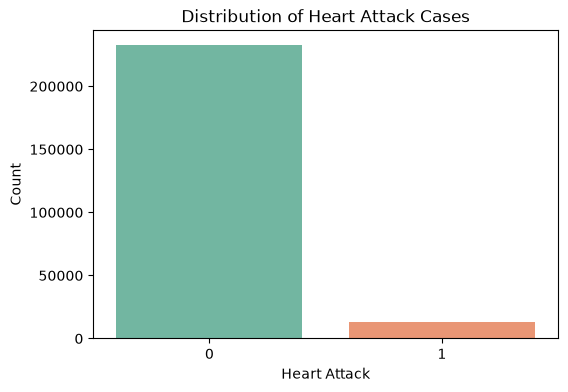

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="HadHeartAttack",
    palette="Set2"
)

plt.title("Distribution of Heart Attack Cases")
plt.xlabel("Heart Attack")
plt.ylabel("Count")

plt.show()

### Numerical Feature Distributions

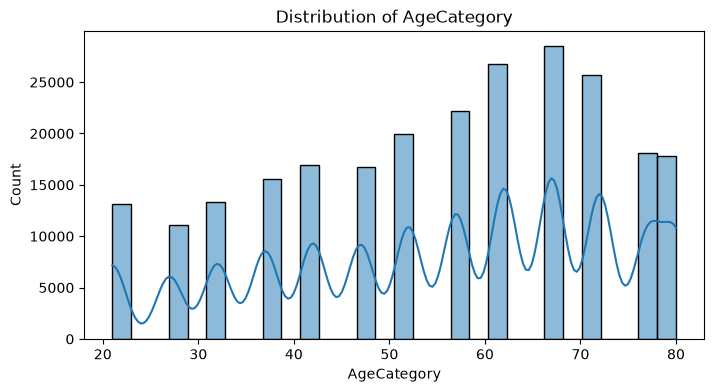

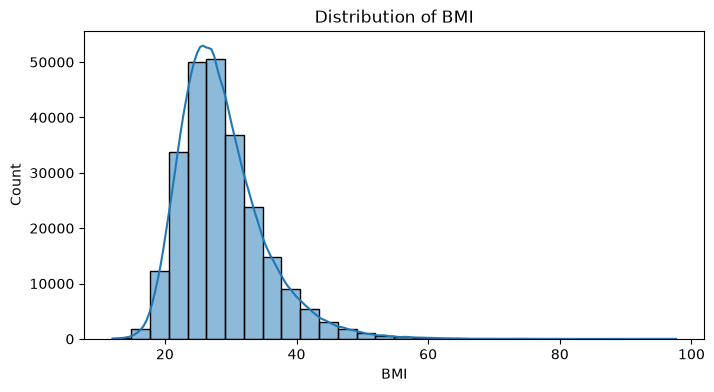

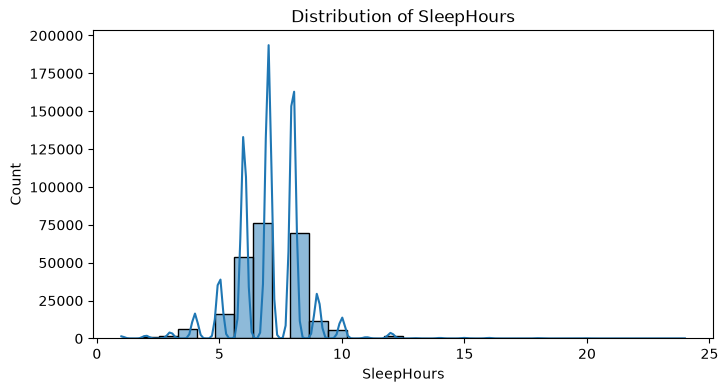

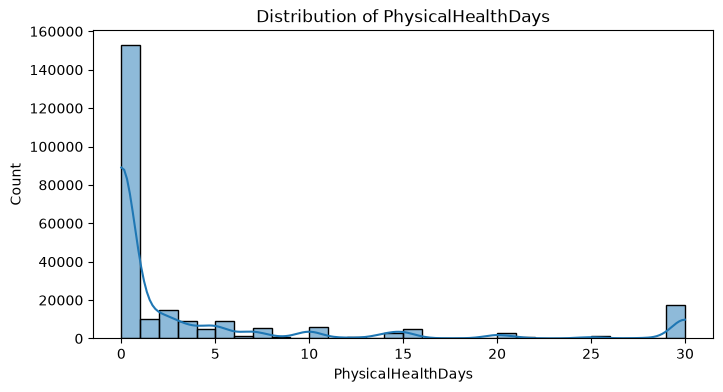

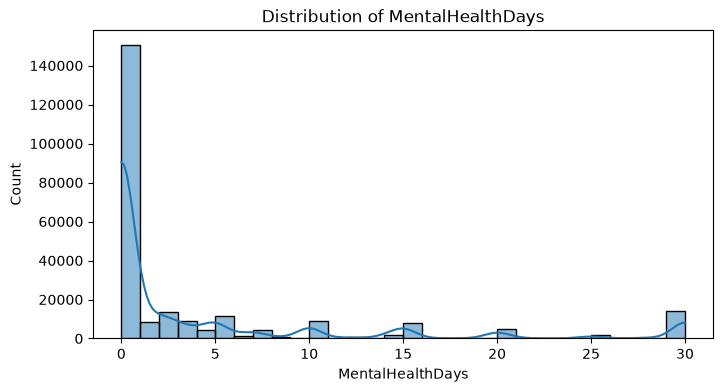

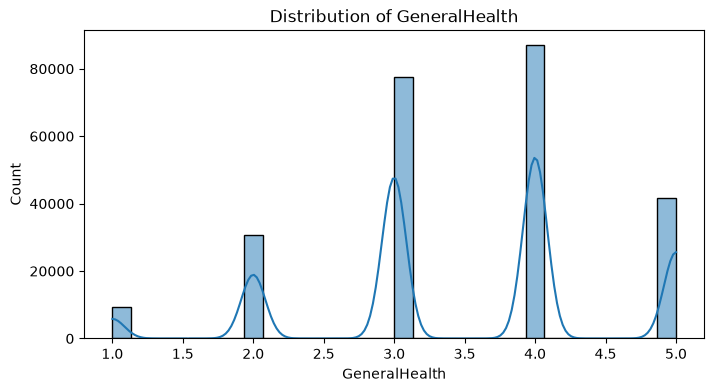

In [19]:
numerical_features = [
    "AgeCategory",
    "BMI",
    "SleepHours",
    "PhysicalHealthDays",
    "MentalHealthDays",
    "GeneralHealth"
]

for col in numerical_features:

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[col],
        bins=30,
        kde=True
    )
    plt.title(f"Distribution of {col}")
    plt.show()



### Correlation Analysis

In [20]:
numeric_df = df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()

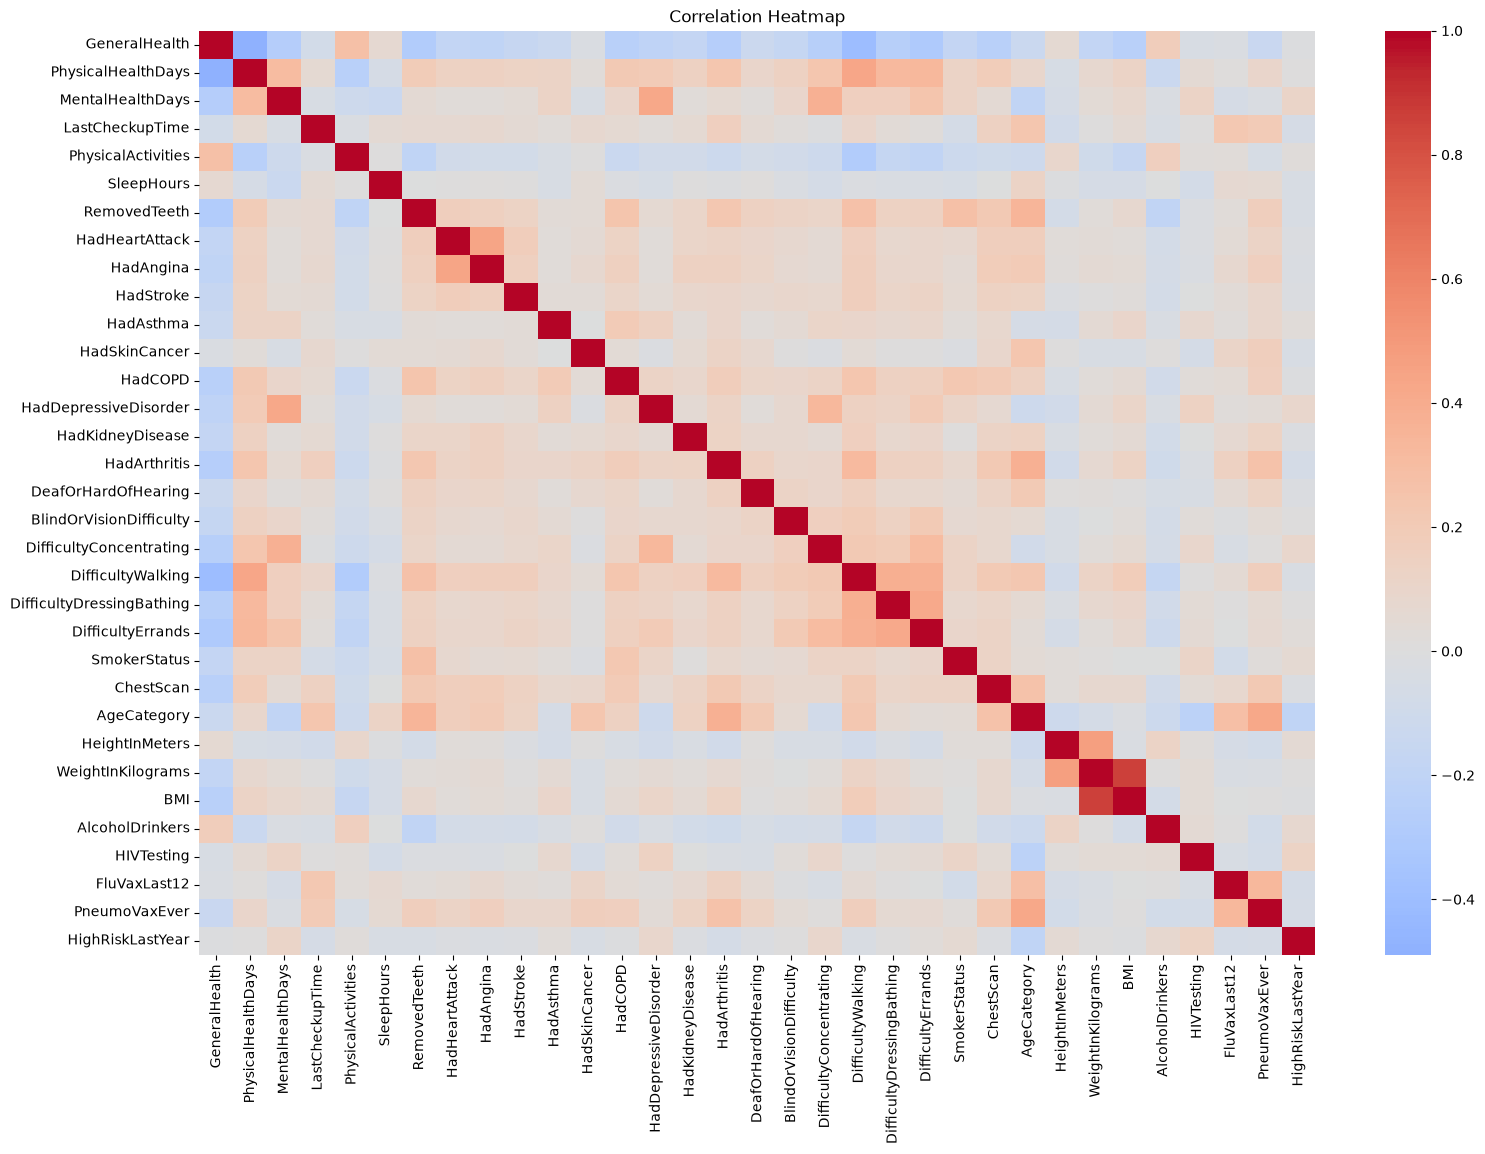

In [23]:
plt.figure(figsize=(18,12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

Correlation Analysis with "HadHeartAttack" target

In [24]:
target_corr = corr_matrix["HadHeartAttack"] \
    .sort_values(ascending=False)
print(target_corr.head(20))

HadHeartAttack               1.000000
HadAngina                    0.445902
HadStroke                    0.177149
AgeCategory                  0.170944
ChestScan                    0.167766
RemovedTeeth                 0.165903
DifficultyWalking            0.159884
PhysicalHealthDays           0.133422
HadCOPD                      0.133220
PneumoVaxEver                0.119965
HadArthritis                 0.117772
HadKidneyDisease             0.109353
DeafOrHardOfHearing          0.097660
DifficultyErrands            0.089492
DifficultyDressingBathing    0.083089
SmokerStatus                 0.077334
BlindOrVisionDifficulty      0.072962
LastCheckupTime              0.065757
DifficultyConcentrating      0.051661
HadSkinCancer                0.049415
Name: HadHeartAttack, dtype: float64


Strongest Correlations to Heart Attack

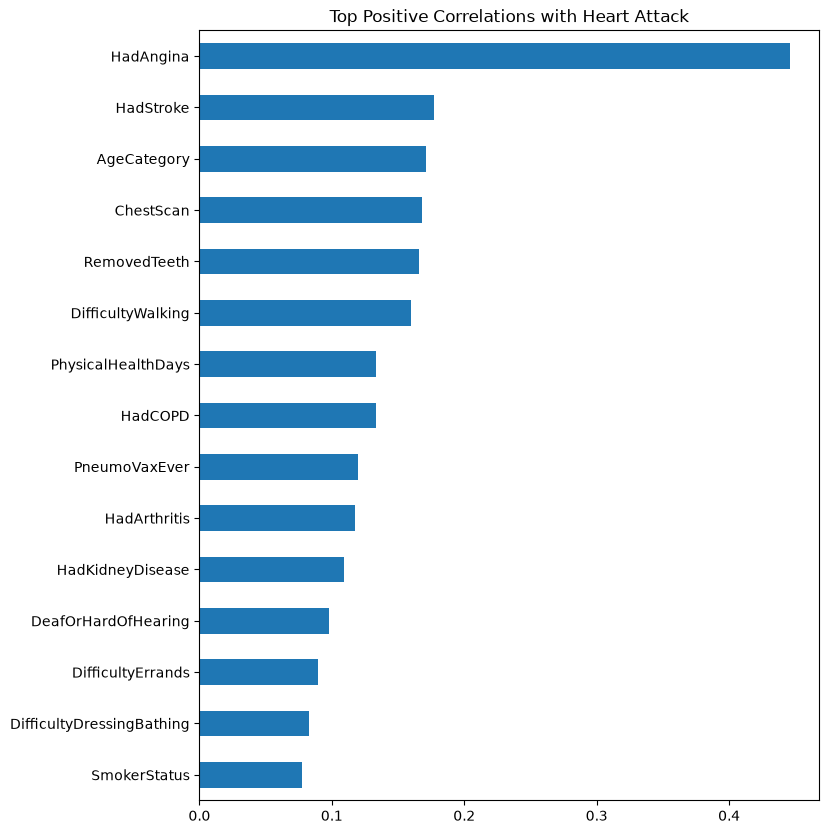

In [25]:
heart_corr = (
    corr_matrix["HadHeartAttack"]
    .drop("HadHeartAttack")
    .sort_values()
)

plt.figure(figsize=(8,10))

heart_corr.tail(15).plot(kind="barh")

plt.title("Top Positive Correlations with Heart Attack")

plt.show()

### Heart Attack Rate by Age

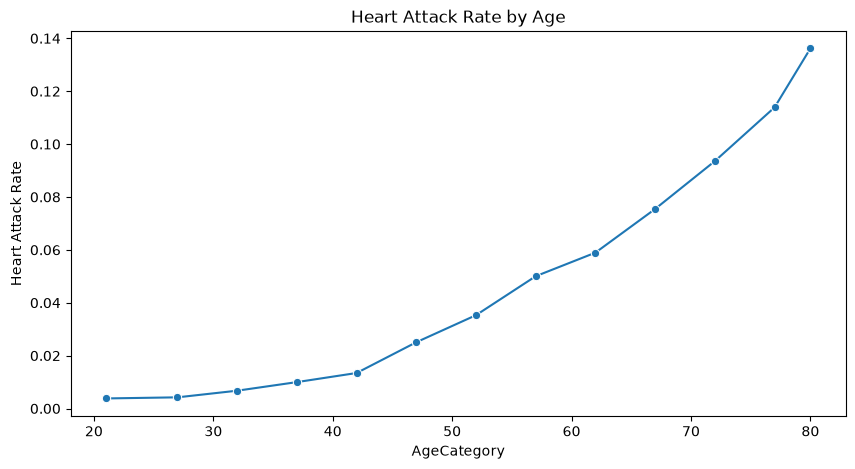

In [28]:
age_risk = (
    df.groupby("AgeCategory")["HadHeartAttack"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=age_risk,
    x="AgeCategory",
    y="HadHeartAttack",
    marker="o"
)

plt.title("Heart Attack Rate by Age")
plt.ylabel("Heart Attack Rate")

plt.show()

### Smoking Status and Heart Attack Risk

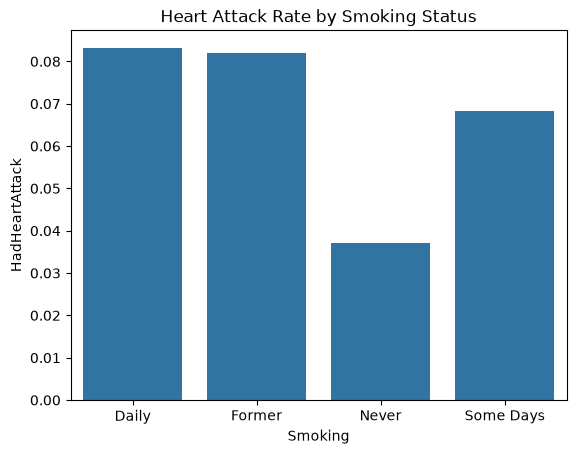

In [32]:
smoking_labels = {
0:"Never",
1:"Former",
2:"Some Days",
3:"Daily"
}

smoking_df = df.copy()

smoking_df["Smoking"] = (
smoking_df["SmokerStatus"]
.map(smoking_labels)
)

smoking_risk = (
    smoking_df.groupby("Smoking")["HadHeartAttack"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=smoking_risk,
    x="Smoking",
    y="HadHeartAttack"
)
plt.title("Heart Attack Rate by Smoking Status")
plt.show()

### BMI and Heart Attack Risk

In [33]:
df["BMI_Category"] = pd.cut(
    df["BMI"],
    bins=[0,18.5,25,30,35,100],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obese I",
        "Obese II+"

    ]
)

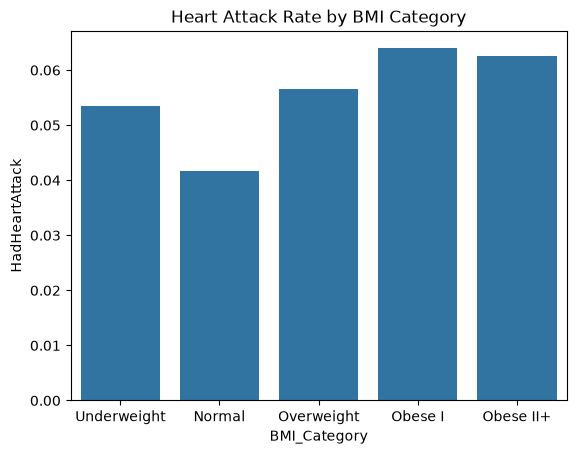

In [34]:
bmi_risk = (
    df.groupby("BMI_Category")["HadHeartAttack"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=bmi_risk,
    x="BMI_Category",
    y="HadHeartAttack"
)

plt.title("Heart Attack Rate by BMI Category")
plt.show()

### Sex and Risk for Heart Attack

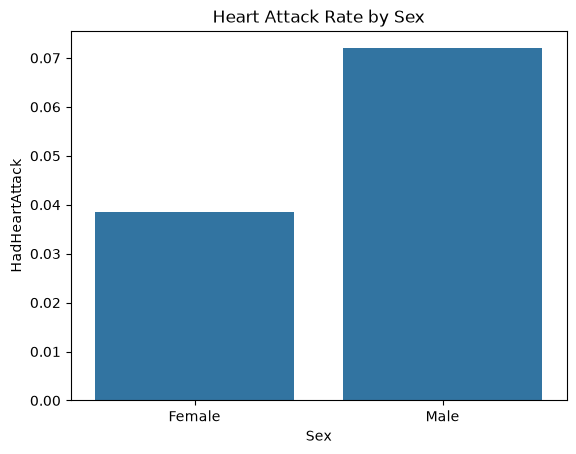

In [35]:
sex_risk = (
df.groupby("Sex")["HadHeartAttack"]
.mean()
.reset_index()
)

sns.barplot(
data=sex_risk,
x="Sex",
y="HadHeartAttack"
)

plt.title("Heart Attack Rate by Sex")

plt.show()

### Pre-Existing Conditions and Heart Attack Risk

In [38]:
conditions = [
    "HadAngina",
    "HadStroke",
    "HadCOPD",
    "HadKidneyDisease",
    "HadArthritis",
    "HadAsthma"
]

results = []
for condition in conditions:

    rate = (
        df.groupby(condition)["HadHeartAttack"]
        .mean()[1]
    )
    results.append([condition,rate])

risk_df = pd.DataFrame(
    results,
    columns=["Condition", "HeartAttackRate"]
)

risk_df = risk_df.sort_values(
    "HeartAttackRate",
    ascending = False
)

risk_df

,Condition,HeartAttackRate
0,HadAngina,0.452886
1,HadStroke,0.249036
3,HadKidneyDisease,0.167937
2,HadCOPD,0.159261
4,HadArthritis,0.091481
5,HadAsthma,0.067539


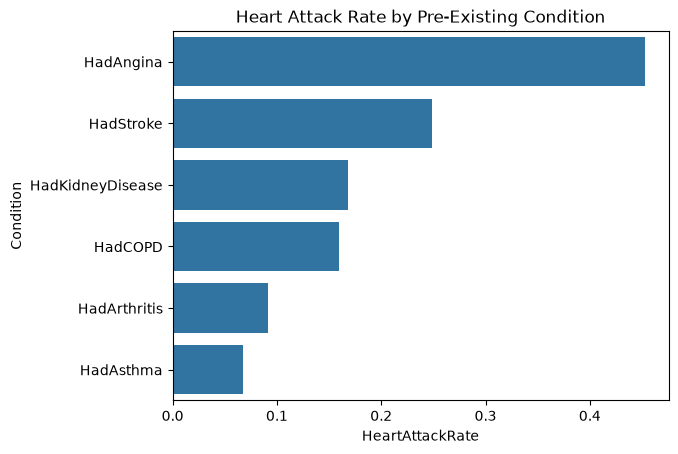

In [39]:
sns.barplot(
    data=risk_df,
    x="HeartAttackRate",
    y="Condition"
)

plt.title("Heart Attack Rate by Pre-Existing Condition")

plt.show()

### Comparison of Numerical Variables across Heart Attack History

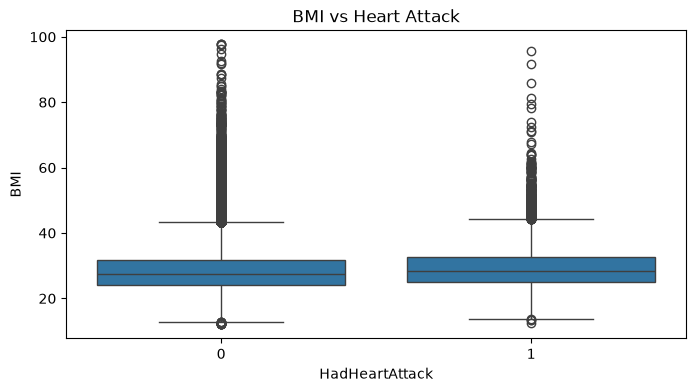

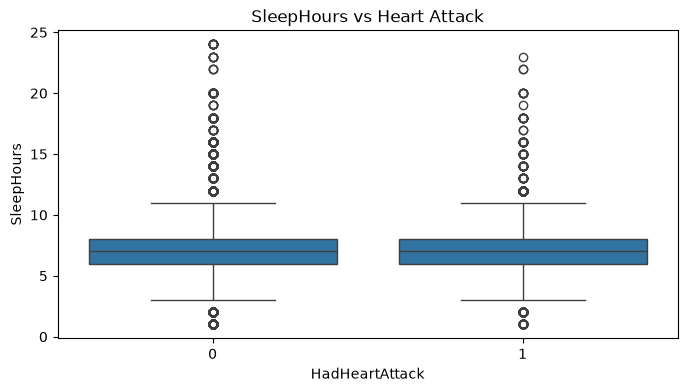

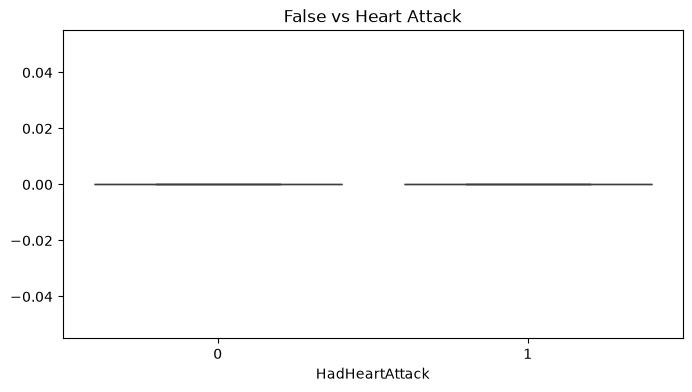

In [40]:
features = [
    "BMI",
    "SleepHours",
    "PhysicalHealthDays"<
    "MentalHealthDays"
]

for feature in features:
    plt.figure(figsize=(8,4))

    sns.boxplot(
        data=df,
        x="HadHeartAttack",
        y=feature
    )

    plt.title(f"{feature} vs Heart Attack")
    plt.show()